# Unsupervised Learning · PR 1 — Mall Customer Segmentation

**Algorithms:** K-Means · Agglomerative Hierarchical · DBSCAN  
**Dataset:** Mall Customer Segmentation Data (Kaggle, CC0) — 200 customers  
**Student:** Herit · Red & White Skill Education

**Jump to a task:**
[Task 1: EDA](#task1) ·
[Task 2: Scaling](#task2) ·
[Task 3: K-Means](#task3) ·
[Task 4: Hierarchical](#task4) ·
[Task 5: DBSCAN](#task5) ·
[Task 6: Comparison & Insights](#task6) ·
[Task 7: Quality & Submission](#task7)

## Setup — Imports and Plot Style

All libraries are imported once here. A single seaborn style (`whitegrid`) and the Red `#CC0000` accent colour are used for every plot in the notebook.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [5]:
sns.set_style('whitegrid')
RED = '#CC0000'
plt.rcParams.update({
    'axes.titlecolor': RED,
    'axes.titleweight': 'bold',
    'axes.edgecolor': RED,
    'axes.linewidth': 1.2,
})

set1_palette = dict(enumerate(sns.color_palette('Set1', 8)))
set2_palette = dict(enumerate(sns.color_palette('Set2', 8)))

os.makedirs('screenshots', exist_ok=True)

<a id="task1"></a>
# Task 1: Data Loading & Exploratory Data Analysis (EDA)

**Objective:** Load the Mall Customers data, clean the column names, encode Gender and understand every feature before any clustering is done.

**Expected output:** A confirmed 200 × 5 dataset with zero nulls, a clean 4-column DataFrame, histograms with KDE curves, a pairplot, an annotated correlation heatmap and a short written summary of what the EDA shows.

## 1.1 Load the dataset

In [6]:
df = pd.read_csv('../Dataset/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
print('Shape:', df.shape)
print('Total null values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

Shape: (200, 5)
Total null values: 0
Duplicate rows: 0


**Observation:** The file has 200 rows and 5 columns, no null values and no duplicate rows, so no cleaning of missing data is needed. Ages run from 18 to 70, annual income from 15k to 137k dollars and the spending score from 1 to 99.

## 1.2 Rename and drop columns

In [10]:
df = df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score',
})
df = df.drop(columns='CustomerID')
print('Columns:', list(df.columns), '| Shape:', df.shape)
df.head()

Columns: ['Gender', 'Age', 'Annual_Income', 'Spending_Score'] | Shape: (200, 4)


,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


**Observation:** `CustomerID` is only an identifier, so keeping it would add a meaningless number to every distance calculation. Dropping it leaves the 4 columns Gender, Age, Annual_Income and Spending_Score.

## 1.3 Encode Gender

In [11]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'Female': 0, 'Male': 1}


In [12]:
df['Gender'].value_counts().rename({0: 'Female (0)', 1: 'Male (1)'})

Gender
Female (0)    112
Male (1)       88
Name: count, dtype: int64

**Observation:** `LabelEncoder` sorts the labels alphabetically, so Female becomes 0 and Male becomes 1, exactly the mapping the task asks for. There are 112 female and 88 male customers, which is a small imbalance.

In [13]:
df_eda = df.copy()

## 1.4 Univariate distributions

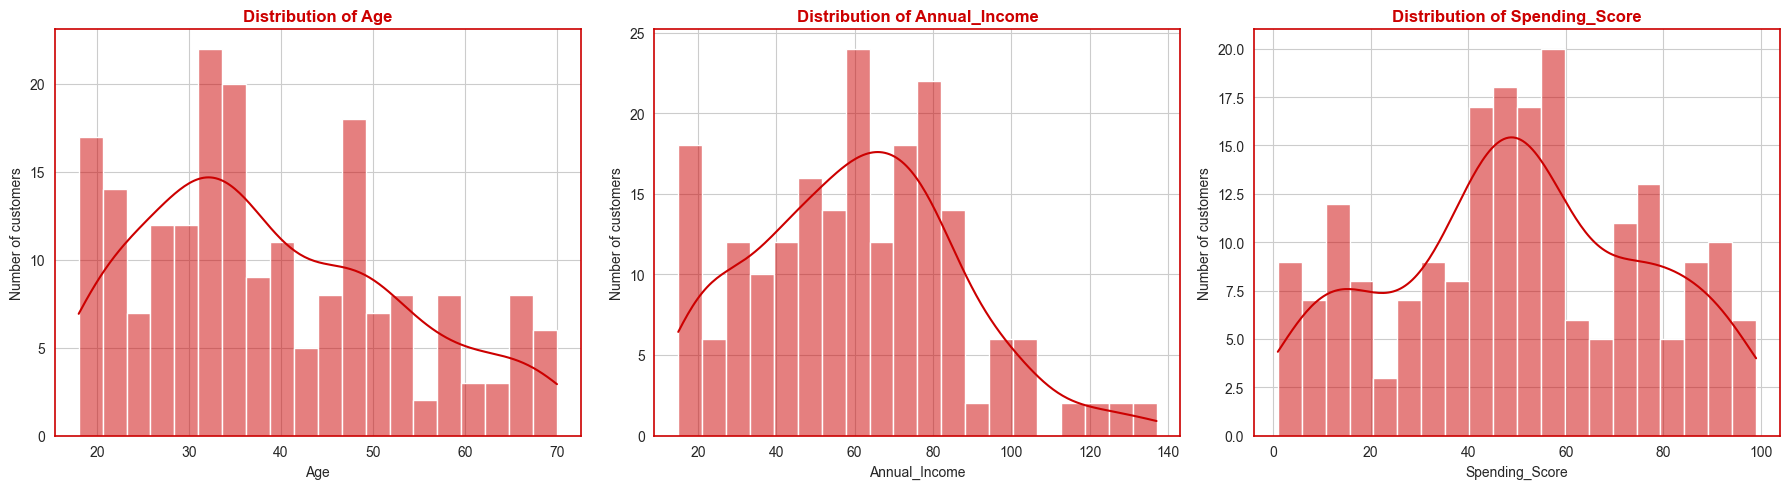

In [14]:
features = ['Age', 'Annual_Income', 'Spending_Score']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, features):
    sns.histplot(df_eda[col], kde=True, bins=20, color=RED, edgecolor='white', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.savefig('screenshots/01_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Age is concentrated between about 25 and 50. Annual income is right-skewed, with most customers between 40k and 80k and a thin tail up to 137k. Spending score is centred near 50 but is spread across the full 1–99 range, so there are real low and high spenders.

## 1.5 Pairplot and correlation heatmap

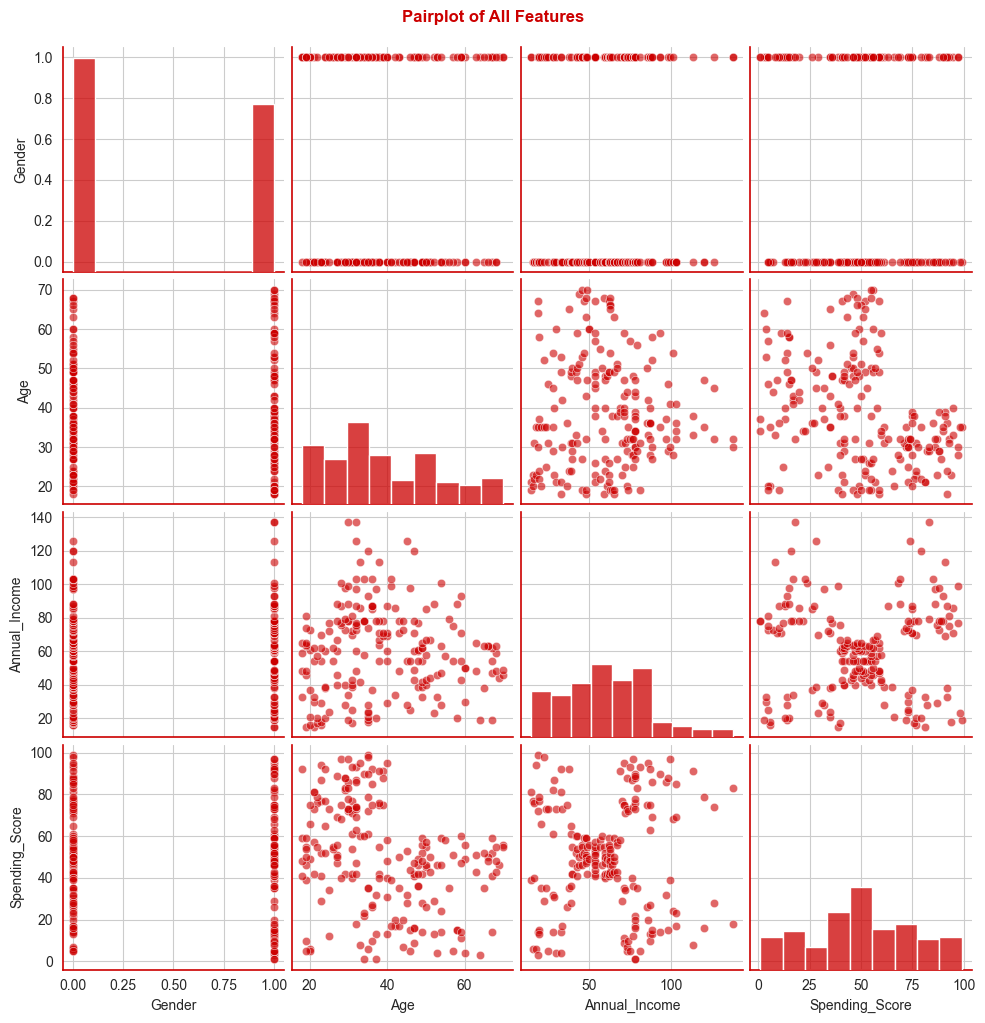

In [15]:
pair_grid = sns.pairplot(df_eda, hue=None, plot_kws={'color': RED, 'alpha': 0.6}, diag_kws={'color': RED})
pair_grid.figure.suptitle('Pairplot of All Features', y=1.02, color=RED, fontweight='bold')
pair_grid.savefig('screenshots/02_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

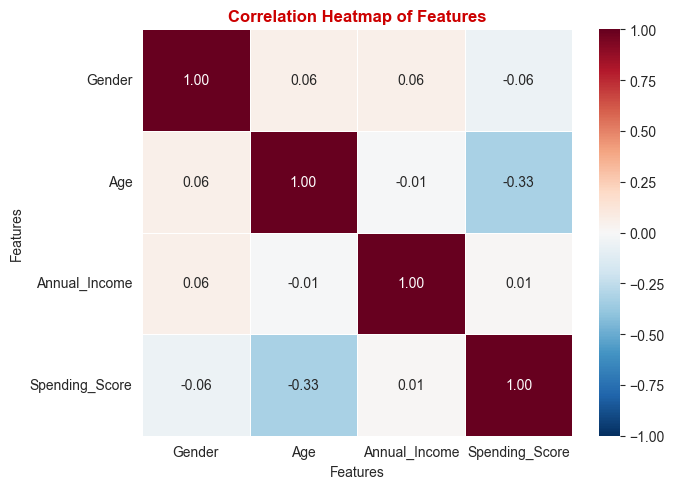

In [16]:
plt.figure(figsize=(7, 5))
sns.heatmap(df_eda.corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('screenshots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 EDA summary

**What the EDA tells us:**

- **Correlations are weak.** The only noticeable one is Age vs Spending_Score (about −0.33): younger customers tend to have higher spending scores. Annual_Income vs Spending_Score is almost 0 (0.01), and Gender is close to 0 with every other feature.
- **Zero correlation does not mean no structure.** A correlation coefficient only measures a straight-line trend. The Annual_Income vs Spending_Score panel of the pairplot shows five separate dense groups, which is exactly what clustering can find and a correlation number cannot.
- **Age vs Spending_Score has a wedge shape.** Customers with high scores are mostly younger, while older customers stay in the low to middle range, but there are no clearly separated groups in this panel.
- **Best two features: Annual_Income and Spending_Score.** They are the only pair that produces well-defined dense groups, they are uncorrelated so each adds independent information, and they are easy to explain to a business (what a customer can afford vs what they actually spend). Age and Gender do not show any group structure on their own.

<a id="task2"></a>
# Task 2: Feature Scaling & Feature Selection

**Objective:** Put Age, Annual_Income and Spending_Score on the same scale and choose the 2-feature subset used for the main clustering tasks.

**Expected output:** A scaled DataFrame `df_scaled` (mean ≈ 0, standard deviation ≈ 1 for the scaled columns) and the 2-feature DataFrame `df_2f`.

## 2.1 Scale features

In [17]:
scale_cols = ['Age', 'Annual_Income', 'Spending_Score']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[scale_cols])

df_scaled = pd.DataFrame(scaled_values, columns=scale_cols)
df_scaled.insert(0, 'Gender', df['Gender'].values)
df_scaled.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


In [18]:
pd.DataFrame({
    'mean': df_scaled.mean().round(3),
    'std': df_scaled.std(ddof=0).round(3),
})

,mean,std
Gender,0.44,0.496
Age,-0.00,1.000
Annual_Income,-0.00,1.000
Spending_Score,-0.00,1.000


**Observation:** The three scaled columns now have a mean of 0 and a standard deviation of 1. Gender was left untouched because it is already a 0/1 column.

## 2.2 Select the 2-feature subset

In [19]:
df_2f = df_scaled[['Annual_Income', 'Spending_Score']]
df_2f.head()

,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


**Note:** `df_2f` (Annual_Income + Spending_Score) is used for all the main clustering tasks below because it gives clearly separable groups and can be drawn directly on a 2D scatter plot without PCA. Using all 4 features is also valid, and it is tested as an extension at the end of Task 6.

## 2.3 Why scaling is needed

In [20]:
df[['Age', 'Annual_Income', 'Spending_Score']].agg(['min', 'max', 'std']).T.assign(range=lambda t: t['max'] - t['min'])

,min,max,std,range
Age,18.0,70.0,13.969007,52.0
Annual_Income,15.0,137.0,26.264721,122.0
Spending_Score,1.0,99.0,25.823522,98.0


**Why StandardScaler is applied before clustering:**

K-Means, Hierarchical (Ward) and DBSCAN all decide which points are "close" using **Euclidean distance**. Distance adds up squared differences across all features, so a feature with a bigger numeric range automatically gets a bigger say. The table above shows that the raw features do not live on the same scale (Annual_Income spans 122 units, Spending_Score 98 and Age 52), and Gender only spans 0 to 1. Without scaling, the feature with the largest spread would dominate every distance calculation and the clusters would mostly reflect that one feature.

`StandardScaler` converts every feature to `(value − mean) / standard deviation`, so each one has mean 0 and standard deviation 1 and contributes equally. It matters for DBSCAN as well, because a single `eps` radius is only meaningful if all axes use the same units.

For the 2-feature case the effect is modest because income and spending score are already in similar ranges, but scaling is essential as soon as Age or Gender is added, and it makes the `eps` values used later easy to interpret.

<a id="task3"></a>
# Task 3: K-Means Clustering

**Objective:** Choose the best number of clusters *k* with the Elbow method and the Silhouette score, fit K-Means and describe the customer segments it finds.

**Expected output:** An elbow plot, a silhouette plot, a scatter plot with 5 labelled clusters and black X centroids, and a styled cluster profile table with a named segment for each cluster.

## 3.1 Elbow Method

In [21]:
k_values = list(range(1, 11))
inertia_values = []
for k in k_values:
    km_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_model.fit(df_2f)
    inertia_values.append(km_model.inertia_)

elbow_df = pd.DataFrame({'k': k_values, 'Inertia': inertia_values})
elbow_df['Drop_%'] = (-elbow_df['Inertia'].pct_change() * 100).round(1)
elbow_df.round(2)

,k,Inertia,Drop_%
0,1,400.00,NaN
1,2,269.69,32.6
2,3,157.70,41.5
3,4,108.92,30.9
4,5,65.57,39.8
5,6,55.06,16.0
6,7,44.86,18.5
7,8,37.23,17.0
8,9,32.39,13.0
9,10,29.98,7.4


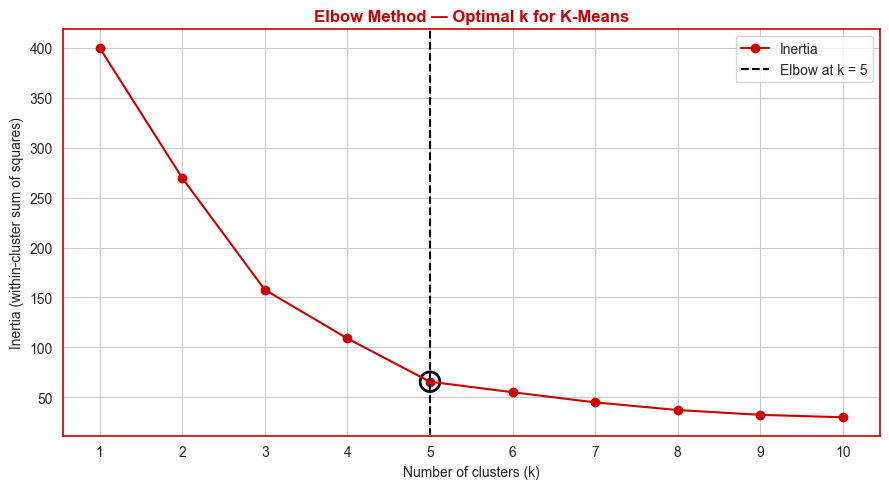

In [22]:
elbow_k = 5

plt.figure(figsize=(9, 5))
plt.plot(elbow_df['k'], elbow_df['Inertia'], marker='o', color=RED, label='Inertia')
plt.axvline(elbow_k, color='black', linestyle='--', label=f'Elbow at k = {elbow_k}')
plt.scatter([elbow_k], [elbow_df.loc[elbow_k - 1, 'Inertia']], s=200, facecolors='none', edgecolors='black', linewidths=2)
plt.title('Elbow Method — Optimal k for K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/04_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

**What inertia measures:** Inertia is the sum of squared distances from every point to the centroid of its own cluster. A small value means tight, compact clusters. It always goes down as *k* increases (with k = 200 it would be 0), so the lowest inertia is not the goal by itself.

**Why the elbow is a good k:** The curve drops steeply while each new cluster splits a genuinely separate group, then flattens once extra clusters only cut up groups that already exist. In the table, going from 4 to 5 clusters reduces inertia by about 40%, but going from 5 to 6 reduces it by only about 16%. The bend is at **k = 5**.

## 3.2 Silhouette Score

In [23]:
sil_k_values = list(range(2, 11))
sil_scores = []
for k in sil_k_values:
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(df_2f)
    sil_scores.append(silhouette_score(df_2f, labels_k))

sil_df = pd.DataFrame({'k': sil_k_values, 'Silhouette_Score': sil_scores})
best_k = int(sil_df.loc[sil_df['Silhouette_Score'].idxmax(), 'k'])
sil_df.round(3)

,k,Silhouette_Score
0,2,0.321
1,3,0.467
2,4,0.494
3,5,0.555
4,6,0.540
5,7,0.528
6,8,0.455
7,9,0.457
8,10,0.443


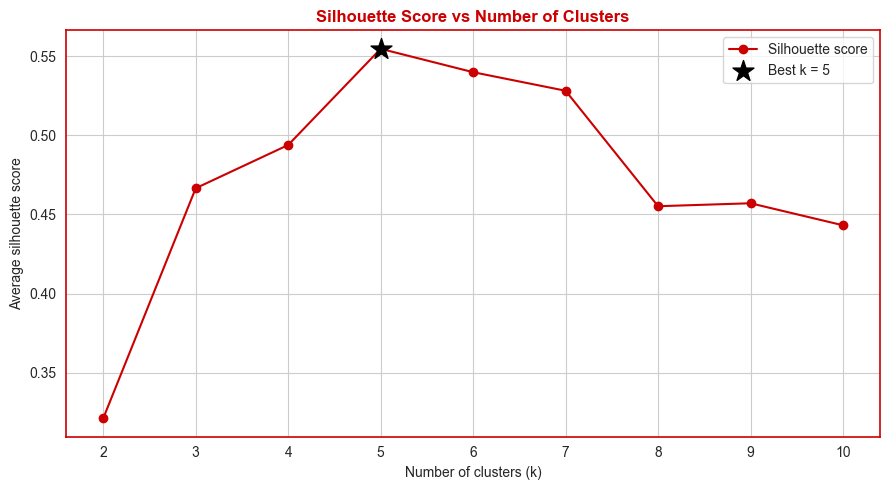

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(sil_df['k'], sil_df['Silhouette_Score'], marker='o', color=RED, label='Silhouette score')
plt.scatter([best_k], [sil_df['Silhouette_Score'].max()], s=250, marker='*', color='black', zorder=3, label=f'Best k = {best_k}')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average silhouette score')
plt.xticks(sil_k_values)
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/05_silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

**How to read it:** For each customer the silhouette compares the average distance to its own cluster (*a*) with the average distance to the nearest other cluster (*b*): `(b − a) / max(a, b)`. It ranges from −1 to 1, and higher means the customer is well matched to its own cluster and far from the others. The k with the highest average score is the data-driven choice.

**Elbow vs Silhouette:** Both methods point to **k = 5** (silhouette ≈ 0.555), so there is no discrepancy here. The silhouette curve is close for k = 6 (≈ 0.54), but the elbow shows that a sixth cluster adds little, so k = 5 is chosen. The elbow method is a visual judgement and can be ambiguous on other data, which is why the two are used together.

## 3.3 Fit the final K-Means model

In [25]:
final_k = best_k
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df_2f)
df['KMeans_Cluster'].value_counts().sort_index().rename('Customers')

KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: Customers, dtype: int64

## 3.4 Visualise the K-Means clusters

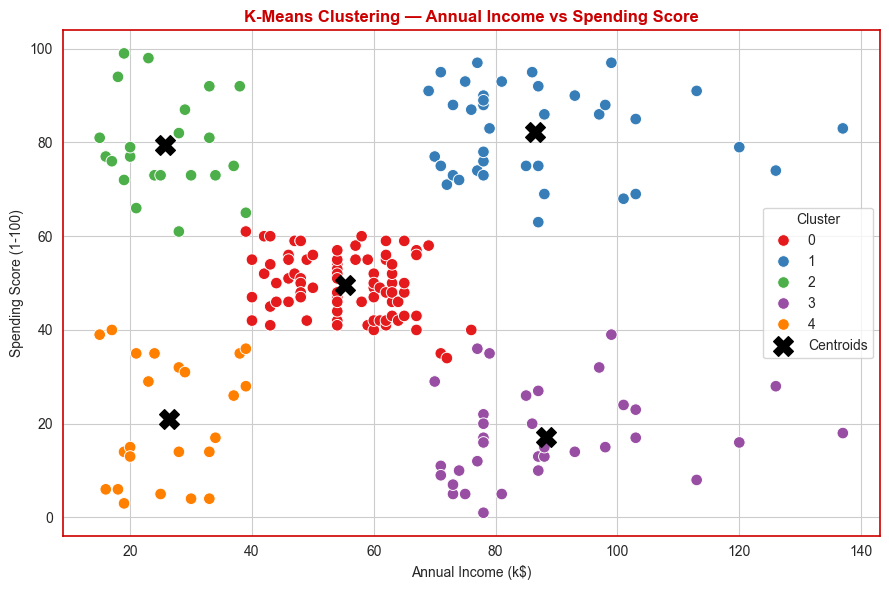

In [26]:
centroids_orig = kmeans.cluster_centers_ * scaler.scale_[1:] + scaler.mean_[1:]

plt.figure(figsize=(9, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette=set1_palette, s=70)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('screenshots/06_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Note:** The model was trained on the scaled data, so `kmeans.cluster_centers_` are in scaled units. The plot uses the original units (k$ and score), so the centroids are converted back with `centroid × scale_ + mean_` to sit at the centre of each group.

## 3.5 Cluster profile table

In [27]:
profile_cols = ['Age', 'Annual_Income', 'Spending_Score']

kmeans_profile = df.groupby('KMeans_Cluster')[profile_cols].mean()
kmeans_profile['Customers'] = df['KMeans_Cluster'].value_counts().sort_index()

income_level = pd.cut(kmeans_profile['Annual_Income'], bins=[0, 40, 70, 200], labels=['Low', 'Average', 'High'])
spend_level = pd.cut(kmeans_profile['Spending_Score'], bins=[0, 40, 60, 100], labels=['Low', 'Average', 'High'])
kmeans_profile['Segment'] = income_level.astype(str) + ' Income, ' + spend_level.astype(str) + ' Spenders'

df['KMeans_Segment'] = df['KMeans_Cluster'].map(kmeans_profile['Segment'])

(kmeans_profile.style
    .format({'Age': '{:.1f}', 'Annual_Income': '{:.1f}', 'Spending_Score': '{:.1f}'})
    .background_gradient(cmap='Reds', subset=profile_cols)
    .set_caption('K-Means Cluster Profiles (mean values per cluster)'))

,Age,Annual_Income,Spending_Score,Customers,Segment
KMeans_Cluster,,,,,
0,42.7,55.3,49.5,81,"Average Income, Average Spenders"
1,32.7,86.5,82.1,39,"High Income, High Spenders"
2,25.3,25.7,79.4,22,"Low Income, High Spenders"
3,41.1,88.2,17.1,35,"High Income, Low Spenders"
4,45.2,26.3,20.9,23,"Low Income, Low Spenders"


**Segment names and what each means for the mall marketing team:**

| Segment | Customers | What they look like | Business implication |
|---|---|---|---|
| **High Income, High Spenders** | 39 | Age ≈ 33, income ≈ 86k, score ≈ 82 | The most valuable group: they can afford more and they actually spend. Keeping them loyal matters most. |
| **Low Income, High Spenders** | 22 | Age ≈ 25, income ≈ 26k, score ≈ 79 | Young, enthusiastic shoppers who spend a lot relative to their income. They respond to deals, trends and easy payment options. |
| **High Income, Low Spenders** | 35 | Age ≈ 41, income ≈ 88k, score ≈ 17 | Customers with money who are not engaged with the mall. This is the biggest untapped opportunity. |
| **Low Income, Low Spenders** | 23 | Age ≈ 45, income ≈ 26k, score ≈ 21 | Limited budget and low spending. They are price-sensitive, so only low-cost campaigns make sense. |
| **Average Income, Average Spenders** | 81 | Age ≈ 43, income ≈ 55k, score ≈ 50 | The mainstream core (about 40% of customers). Small improvements here have a large total effect. |

<a id="task4"></a>
# Task 4: Agglomerative Hierarchical Clustering

**Objective:** Build a Ward-linkage dendrogram, choose the number of clusters from it, fit an Agglomerative model and compare it with K-Means.

**Expected output:** A dendrogram with a dashed cut line, a scatter plot of the hierarchical clusters, a side-by-side K-Means vs Hierarchical figure and a cluster profile comparison.

## 4.1 Dendrogram

In [28]:
linked = linkage(df_2f, method='ward')

merge_distances = linked[:, 2]
gaps = np.diff(merge_distances)
widest_gap = gaps.argmax()

cut_height = (merge_distances[widest_gap] + merge_distances[widest_gap + 1]) / 2
n_hier_clusters = len(df_2f) - 1 - widest_gap

print(f'Longest vertical gap: {gaps[widest_gap]:.2f} (between merge distances '
      f'{merge_distances[widest_gap]:.2f} and {merge_distances[widest_gap + 1]:.2f})')
print(f'Cut height: {cut_height:.2f}  ->  {n_hier_clusters} clusters')

Longest vertical gap: 5.10 (between merge distances 4.35 and 9.45)
Cut height: 6.90  ->  5 clusters


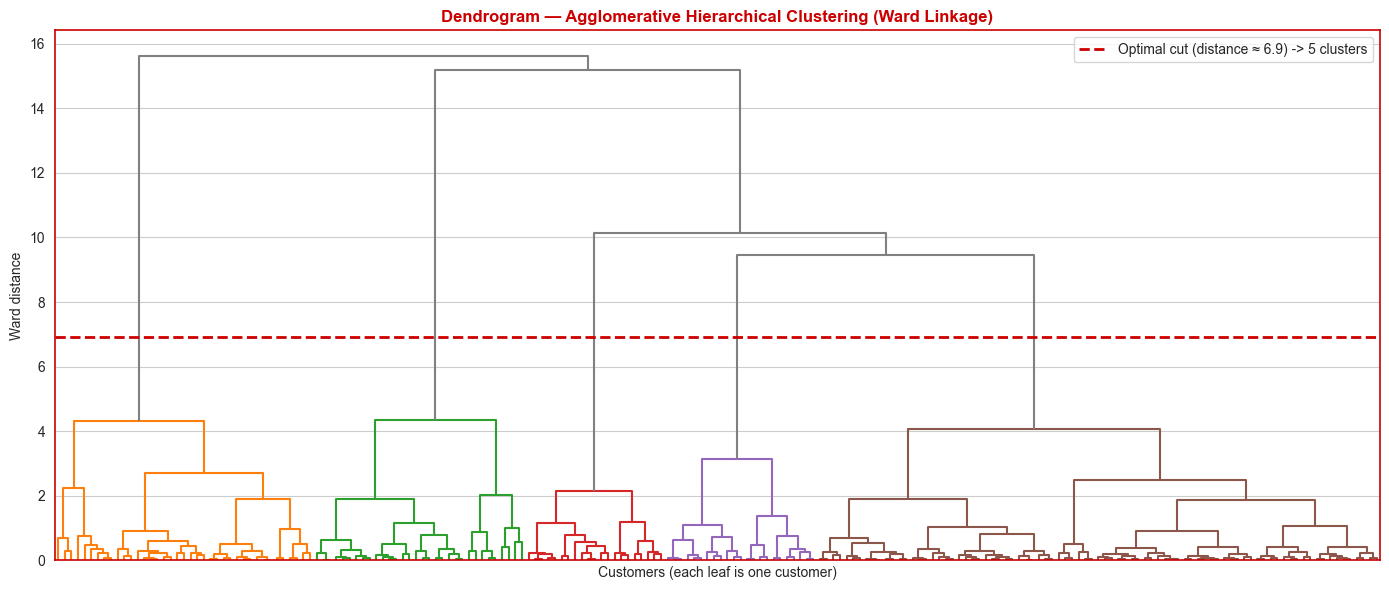

In [29]:
plt.figure(figsize=(14, 6))
dendrogram(linked, color_threshold=cut_height, above_threshold_color='grey', no_labels=True)
plt.axhline(y=cut_height, color=RED, linestyle='--', linewidth=2, label=f'Optimal cut (distance ≈ {cut_height:.1f}) -> {n_hier_clusters} clusters')
plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Customers (each leaf is one customer)')
plt.ylabel('Ward distance')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/07_dendrogram_ward.png', dpi=150, bbox_inches='tight')
plt.show()

**What Ward linkage minimises:** Agglomerative clustering starts with every customer as its own cluster and repeatedly merges the two closest clusters. Ward linkage defines "closest" as the pair whose merge causes the **smallest increase in total within-cluster variance** (the same quantity K-Means minimises). This is why Ward tends to produce compact, similarly sized clusters.

**How to read the dendrogram:** The y-axis is the distance (variance increase) at which two clusters were merged, so a tall vertical line means that merging those clusters is expensive because they are quite different. To choose the number of clusters, find the **longest vertical stretch that no horizontal merge line crosses** and cut through it with a horizontal line. The number of vertical lines the cut crosses is the number of clusters. Here the longest such gap sits between merge distances of about 4.4 and 9.5, and the dashed line cuts it, giving **5 clusters**.

## 4.2 Fit the Agglomerative model

In [30]:
def align_labels(reference, labels):
    ref_ids = np.unique(reference)
    lab_ids = np.unique(labels[labels != -1])
    overlap = np.array([[np.sum((labels == lab) & (reference == ref)) for ref in ref_ids] for lab in lab_ids])
    rows, cols = linear_sum_assignment(-overlap)
    mapping = {lab_ids[r]: ref_ids[c] for r, c in zip(rows, cols)}
    next_id = ref_ids.max() + 1
    for lab in lab_ids:
        if lab not in mapping:
            mapping[lab] = next_id
            next_id += 1
    mapping[-1] = -1
    return np.array([mapping[lab] for lab in labels])

In [31]:
hier = AgglomerativeClustering(n_clusters=n_hier_clusters, linkage='ward')
hier_raw_labels = hier.fit_predict(df_2f)

df['Hier_Cluster'] = align_labels(df['KMeans_Cluster'].values, hier_raw_labels)
df['Hier_Cluster'].value_counts().sort_index().rename('Customers')

Hier_Cluster
0    85
1    39
2    21
3    32
4    23
Name: Customers, dtype: int64

**Note:** Cluster numbers are arbitrary (cluster "0" in one algorithm can be cluster "3" in another). `align_labels` renumbers the hierarchical clusters so that each one gets the same number as the K-Means cluster it overlaps with most. This does not change who is grouped with whom. It only makes colours comparable across the plots.

## 4.3 Visualise the Hierarchical clusters

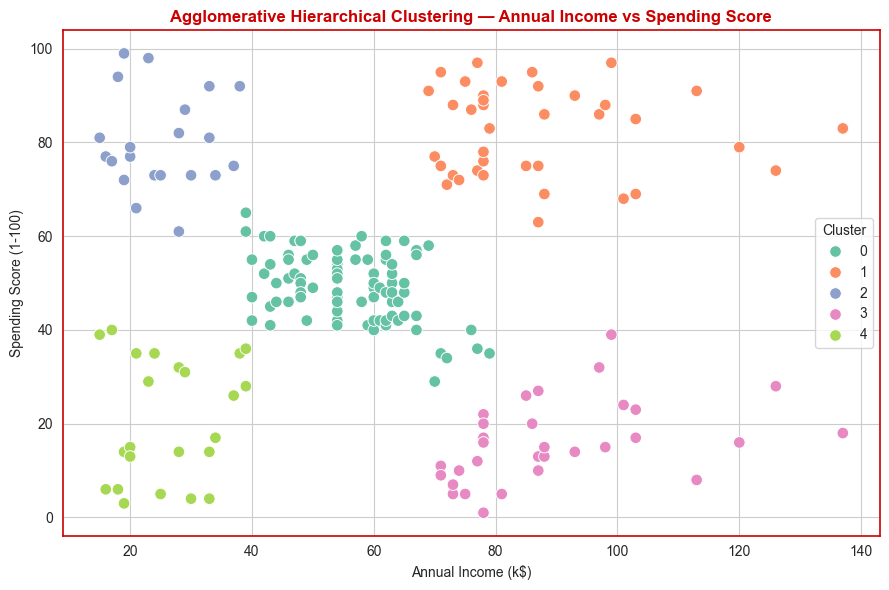

In [32]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Hier_Cluster', data=df, palette=set2_palette, s=70)
plt.title('Agglomerative Hierarchical Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('screenshots/08_hierarchical_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Compare with K-Means

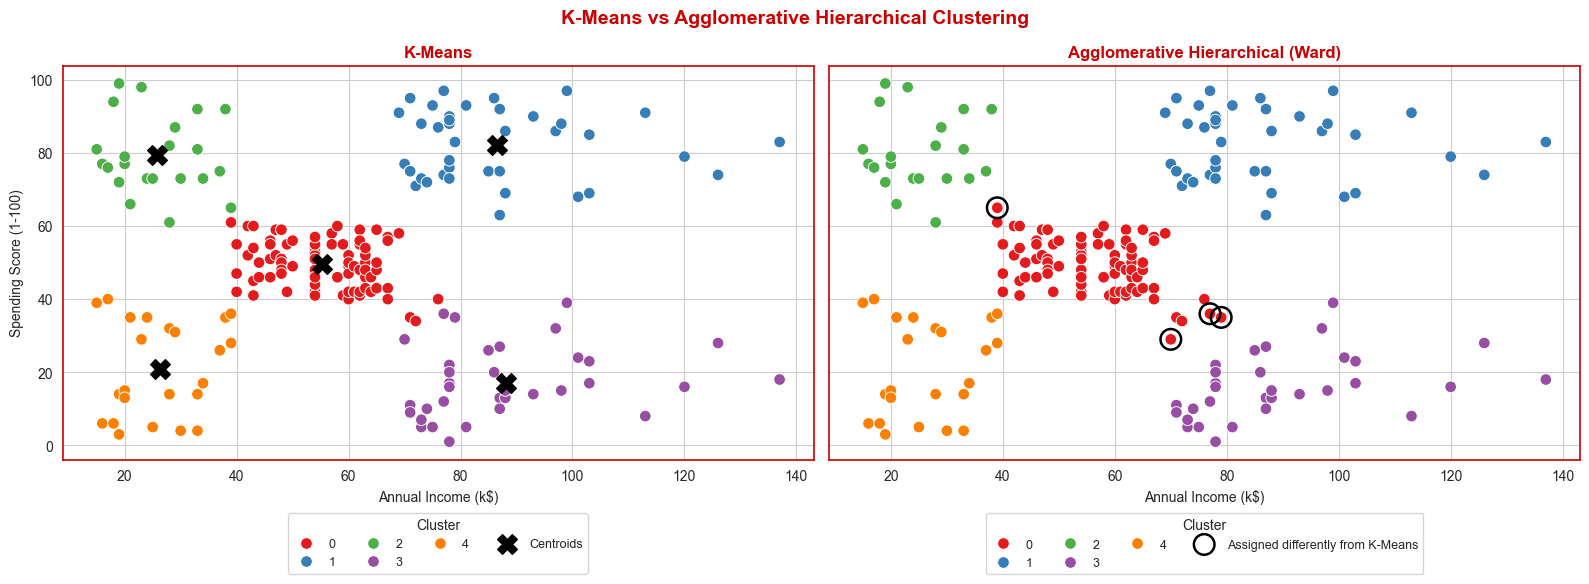

In [33]:
disagree = df['KMeans_Cluster'] != df['Hier_Cluster']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette=set1_palette, s=70, ax=axes[0])
axes[0].scatter(centroids_orig[:, 0], centroids_orig[:, 1], c='black', marker='X', s=200, label='Centroids')
axes[0].set_title('K-Means')

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Hier_Cluster', data=df, palette=set1_palette, s=70, ax=axes[1])
axes[1].scatter(df.loc[disagree, 'Annual_Income'], df.loc[disagree, 'Spending_Score'],
                facecolors='none', edgecolors='black', s=220, linewidths=1.8, label='Assigned differently from K-Means')
axes[1].set_title('Agglomerative Hierarchical (Ward)')

for ax in axes:
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.legend(title='Cluster', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9)

fig.suptitle('K-Means vs Agglomerative Hierarchical Clustering', color=RED, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('screenshots/09_kmeans_vs_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
print('Customers assigned differently:', int(disagree.sum()), 'out of', len(df))
pd.crosstab(df['KMeans_Segment'], df['Hier_Cluster'], rownames=['K-Means segment'], colnames=['Hierarchical cluster'])

Customers assigned differently: 4 out of 200


Hierarchical cluster,0,1,2,3,4
K-Means segment,,,,,
"Average Income, Average Spenders",81,0,0,0,0
"High Income, High Spenders",0,39,0,0,0
"High Income, Low Spenders",3,0,0,32,0
"Low Income, High Spenders",1,0,21,0,0
"Low Income, Low Spenders",0,0,0,0,23


**Do the boundaries agree?** Almost completely: only 4 of 200 customers get a different cluster, and they are circled in the right-hand plot. All of them lie on the boundary between the large Average group and the neighbouring groups, where the customer sits between two clusters.

**Why the border customers differ:** K-Means is **centroid-based**: every customer is assigned to the nearest centroid, so the boundary between two clusters is a straight line halfway between their centroids. Hierarchical clustering is **connectivity-based**: it builds clusters bottom-up by repeatedly merging groups, so a border customer ends up with whichever group it was merged with first, even if a different centroid is slightly closer. When groups are well separated both give the same answer, and they only differ where the groups touch.

## 4.5 Cluster profile table

In [35]:
hier_profile = df.groupby('Hier_Cluster')[profile_cols].mean()
hier_profile['Customers'] = df['Hier_Cluster'].value_counts().sort_index()
hier_profile['Segment'] = kmeans_profile['Segment']

(hier_profile.style
    .format({'Age': '{:.1f}', 'Annual_Income': '{:.1f}', 'Spending_Score': '{:.1f}'})
    .background_gradient(cmap='Reds', subset=profile_cols)
    .set_caption('Hierarchical Cluster Profiles (mean values per cluster)'))

,Age,Annual_Income,Spending_Score,Customers,Segment
Hier_Cluster,,,,,
0,42.5,55.8,49.1,85,"Average Income, Average Spenders"
1,32.7,86.5,82.1,39,"High Income, High Spenders"
2,25.3,25.1,80.0,21,"Low Income, High Spenders"
3,41.0,89.4,15.6,32,"High Income, Low Spenders"
4,45.2,26.3,20.9,23,"Low Income, Low Spenders"


In [36]:
difference = (hier_profile[profile_cols + ['Customers']] - kmeans_profile[profile_cols + ['Customers']]).round(2)
difference.style.set_caption('Hierarchical minus K-Means (per cluster)')

,Age,Annual_Income,Spending_Score,Customers
Hier_Cluster,,,,
0,-0.230000,0.520000,-0.390000,4
1,0.000000,0.000000,0.000000,0
2,0.060000,-0.630000,0.680000,-1
3,-0.110000,1.210000,-1.520000,-3
4,0.000000,0.000000,0.000000,0


**Are the segment definitions consistent?** Yes. Every hierarchical cluster has almost the same mean age, income and spending score as its K-Means counterpart, so the same five segments appear under the same names. The largest changes are in the two clusters that share the border with the Average group (the High Income, Low Spenders segment loses 3 customers to it and the Low Income, High Spenders segment loses 1), which slightly shifts their averages.

<a id="task5"></a>
# Task 5: DBSCAN Clustering

**Objective:** Tune `eps` and `min_samples` for DBSCAN, fit the final model and see how a density-based method differs from K-Means and Hierarchical clustering.

**Expected output:** A 4-NN distance plot, a grid-search table (clusters, noise, silhouette), a scatter plot with noise points shown as black x markers and a written comparison of the three algorithms.

## 5.1 Parameter tuning — epsilon

In [37]:
nn_model = NearestNeighbors(n_neighbors=4).fit(df_2f)
nn_distances, _ = nn_model.kneighbors(df_2f)
k_distances = np.sort(nn_distances[:, -1])

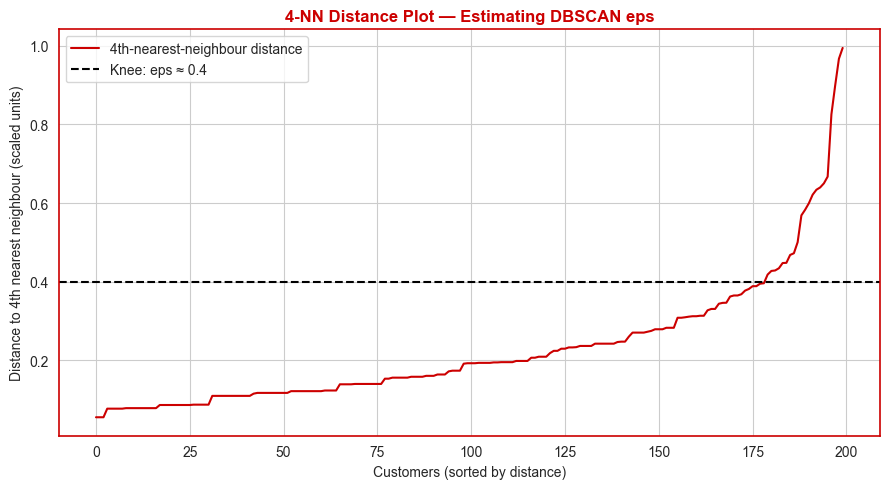

In [38]:
plt.figure(figsize=(9, 5))
plt.plot(k_distances, color=RED, label='4th-nearest-neighbour distance')
plt.axhline(0.4, color='black', linestyle='--', label='Knee: eps ≈ 0.4')
plt.title('4-NN Distance Plot — Estimating DBSCAN eps')
plt.xlabel('Customers (sorted by distance)')
plt.ylabel('Distance to 4th nearest neighbour (scaled units)')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/10_knn_distance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

**How to read it:** For every customer the plot shows how far away its 4th nearest neighbour is (the customer itself counts as the first neighbour, which matches how DBSCAN counts `min_samples`). Customers inside dense groups have small distances, so they form the flat left part of the curve. Isolated customers have large distances and form the steep right end. The **knee** where the curve starts to shoot up marks the distance at which points stop belonging to dense regions, and it is the suggested `eps`. The knee is around **0.4** (roughly 0.4 to 0.5).

## 5.2 Grid search — eps and min_samples

In [39]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

grid_rows = []
for eps in eps_values:
    for min_s in min_samples_values:
        grid_labels = DBSCAN(eps=eps, min_samples=min_s).fit_predict(df_2f)
        n_clusters_found = len(set(grid_labels)) - (1 if -1 in grid_labels else 0)
        n_noise = int((grid_labels == -1).sum())
        keep = grid_labels != -1
        sil = silhouette_score(df_2f[keep], grid_labels[keep]) if n_clusters_found >= 2 else np.nan
        grid_rows.append({
            'eps': eps,
            'min_samples': min_s,
            'n_clusters': n_clusters_found,
            'n_noise': n_noise,
            'noise_%': round(100 * n_noise / len(df_2f), 1),
            'silhouette': sil,
        })

grid_df = pd.DataFrame(grid_rows)
grid_df.style.format({'silhouette': '{:.3f}'}, na_rep='n/a')

,eps,min_samples,n_clusters,n_noise,noise_%,silhouette
0,0.200000,3,13,44,22.000000,0.470
1,0.200000,4,5,73,36.500000,0.617
2,0.200000,5,7,77,38.500000,0.586
3,0.200000,6,4,95,47.500000,0.614
4,0.300000,3,9,14,7.000000,0.472
5,0.300000,4,8,23,11.500000,0.520
6,0.300000,5,7,35,17.500000,0.524
7,0.300000,6,6,48,24.000000,0.530
8,0.400000,3,4,10,5.000000,0.395
9,0.400000,4,3,14,7.000000,0.458


**Choosing the parameters:**

- **eps = 0.2 or 0.3:** the radius is too small, so the real groups break into many small clusters (up to 13) and 14 to 95 customers are marked as noise.
- **eps = 0.5:** the radius is too large, so neighbouring groups merge and only 2 clusters remain.
- **eps = 0.6:** everything collapses into a single cluster, so no silhouette score can be computed.
- **eps = 0.4** (the knee of the k-distance plot) is the balanced choice. Within it, `min_samples = 5` gives 4 coherent clusters with only 15 noise points (7.5%) and a silhouette of about 0.48. `min_samples = 3` finds slightly less coherent clusters (silhouette 0.395) and `min_samples = 6` marks more customers as noise (19) for a small silhouette gain.

**Chosen: eps = 0.4, min_samples = 5.** Note that the silhouette here is computed without the noise points, so it is slightly flattering for settings that discard many points.

## 5.3 Fit the final DBSCAN model

In [40]:
chosen_eps, chosen_min_samples = 0.4, 5

dbscan = DBSCAN(eps=chosen_eps, min_samples=chosen_min_samples)
dbscan_raw_labels = dbscan.fit_predict(df_2f)

df['DBSCAN_Cluster'] = align_labels(df['KMeans_Cluster'].values, dbscan_raw_labels)

print('Clusters found:', df.loc[df['DBSCAN_Cluster'] != -1, 'DBSCAN_Cluster'].nunique())
print('Noise points (label -1):', int((df['DBSCAN_Cluster'] == -1).sum()))
df['DBSCAN_Cluster'].value_counts().sort_index().rename('Customers')

Clusters found: 4
Noise points (label -1): 15


DBSCAN_Cluster
-1     15
 0    115
 1     32
 3     27
 4     11
Name: Customers, dtype: int64

In [41]:
grid_df.query('eps == @chosen_eps and min_samples == @chosen_min_samples')

,eps,min_samples,n_clusters,n_noise,noise_%,silhouette
10,0.4,5,4,15,7.5,0.478059


**Note:** As before, the cluster numbers are matched to the K-Means numbering with `align_labels` (noise stays `-1`) so that colours are comparable across all plots.

## 5.4 Visualise the DBSCAN clusters

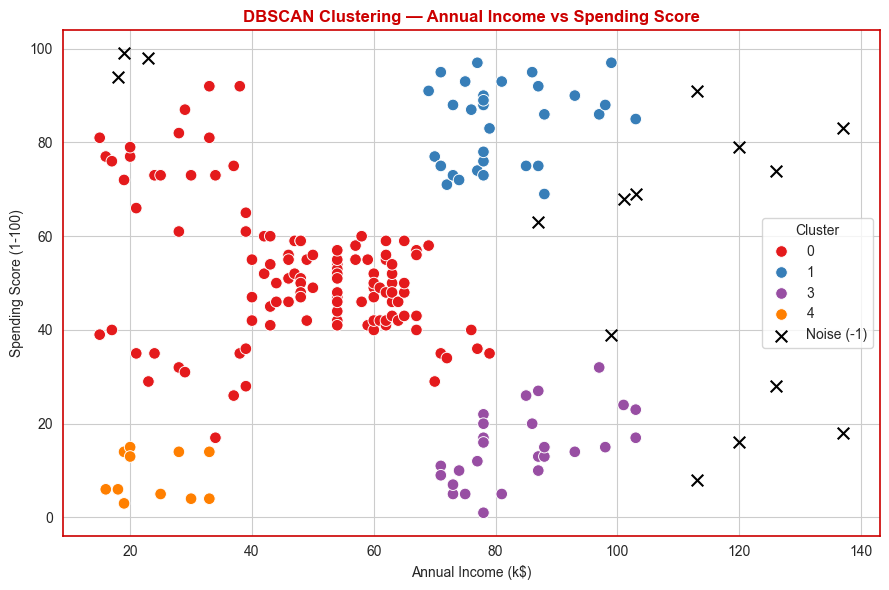

In [42]:
dbscan_noise = df[df['DBSCAN_Cluster'] == -1]
dbscan_clustered = df[df['DBSCAN_Cluster'] != -1]

plt.figure(figsize=(9, 6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='DBSCAN_Cluster', data=dbscan_clustered, palette=set1_palette, s=70)
plt.scatter(dbscan_noise['Annual_Income'], dbscan_noise['Spending_Score'], c='black', marker='x', s=70, label='Noise (-1)')
plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('screenshots/11_dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**What the parameters control:**

- **`eps`** is the radius of the neighbourhood drawn around each point (in scaled units). A larger eps connects more points and merges clusters, while a smaller eps splits them.
- **`min_samples`** is the number of points (including the point itself) that must fall inside that radius for a point to be a **core point** (a point in a dense area). Points inside the radius of a core point but with too few neighbours themselves are **border points**. A cluster is a chain of connected core points plus their border points.

**Why noise points appear:** A point that is neither a core point nor within `eps` of one is too far from any dense region to belong to a cluster, so DBSCAN labels it `-1`. In the plot, the black x markers are the customers at the extremes: 12 of the 15 have incomes of about 87k or more, where customers are sparse, and 3 are low-income customers with unusually high spending scores (94–99).

## 5.5 DBSCAN vs K-Means — shape detection

In [43]:
pd.crosstab(df['KMeans_Segment'], df['DBSCAN_Cluster'], rownames=['K-Means segment'], colnames=['DBSCAN cluster (-1 = noise)'])

DBSCAN cluster (-1 = noise),-1,0,1,3,4
K-Means segment,,,,,
"Average Income, Average Spenders",0,81,0,0,0
"High Income, High Spenders",7,0,32,0,0
"High Income, Low Spenders",5,3,0,27,0
"Low Income, High Spenders",3,19,0,0,0
"Low Income, Low Spenders",0,12,0,0,11


In [44]:
stability = pd.DataFrame({
    'Same_as_KMeans_Hier_%': (df['KMeans_Cluster'] == df['Hier_Cluster']).groupby(df['KMeans_Segment']).mean() * 100,
    'Same_as_KMeans_DBSCAN_%': (df['KMeans_Cluster'] == df['DBSCAN_Cluster']).groupby(df['KMeans_Segment']).mean() * 100,
}).round(1)
stability.style.background_gradient(cmap='Reds', vmin=0, vmax=100).format('{:.1f}')

,Same_as_KMeans_Hier_%,Same_as_KMeans_DBSCAN_%
KMeans_Segment,,
"Average Income, Average Spenders",100.0,100.0
"High Income, High Spenders",100.0,82.1
"High Income, Low Spenders",91.4,77.1
"Low Income, High Spenders",95.5,0.0
"Low Income, Low Spenders",100.0,47.8


**Comparing DBSCAN with K-Means:**

1. **No need to choose k.** DBSCAN infers the number of clusters from density, whereas K-Means needs *k* in advance (chosen above with elbow and silhouette). The price is that DBSCAN needs `eps` and `min_samples`, and the result is sensitive to them (see the grid search).
2. **Arbitrary shapes.** DBSCAN follows dense regions of any shape, while K-Means assumes compact, roughly round clusters around a centroid. This dataset has round blobs, so K-Means suits it well and DBSCAN's flexibility gives no advantage.
3. **Noise handling.** DBSCAN marks 15 low-density customers as noise instead of forcing them into a group, whereas K-Means and Hierarchical assign every customer to a cluster, including the outliers.
4. **Do all three agree on the number of segments?** No. K-Means and Hierarchical both find **5** segments, while DBSCAN finds **4** plus noise. The Average, Low Income High Spenders and part of the Low Income Low Spenders groups touch each other at their edges, so at eps = 0.4 DBSCAN connects them into one large dense cluster. Density-based methods merge groups that are not separated by a low-density gap, and these groups are separated by distance rather than by empty space.
5. **Most stable segments.** The table above shows how many customers of each K-Means segment stay in the matching cluster. **Average Income, Average Spenders** is never split by any algorithm (100% in both), although DBSCAN also pours 34 customers from neighbouring segments into that same cluster. **High Income, High Spenders** (100% Hierarchical, 82% DBSCAN) and **High Income, Low Spenders** (91% and 77%) are also stable, because they sit far from the other groups. The **low-income segments are the least stable**: DBSCAN absorbs every Low Income, High Spenders customer into the big central cluster (0% match) and keeps only 48% of the Low Income, Low Spenders group separate.

<a id="task6"></a>
# Task 6: Algorithm Comparison & Business Insights

**Objective:** Compare the three algorithms visually and with numeric metrics, then turn the K-Means segments into practical recommendations for mall management.

**Expected output:** A 3-panel comparison figure, a metrics table (Silhouette, Davies-Bouldin, Calinski-Harabasz) for all three algorithms, and a structured business insight report.

## 6.1 Three-panel comparison figure

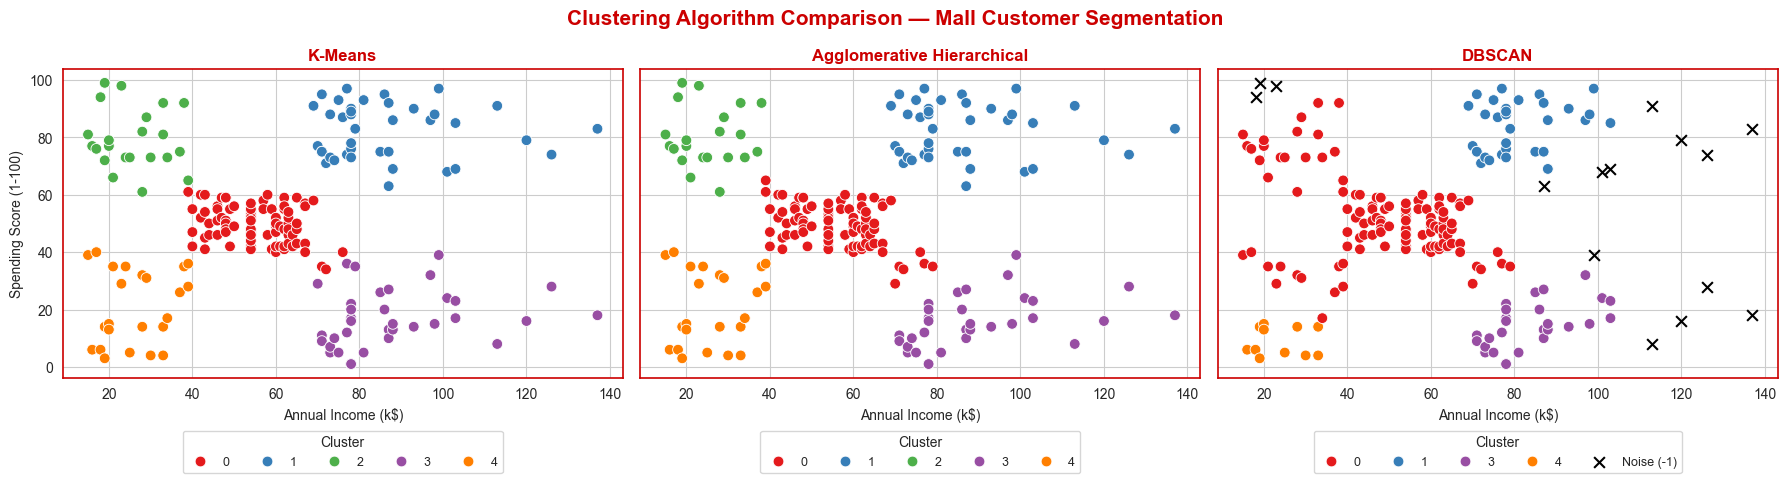

In [45]:
panels = [('KMeans_Cluster', 'K-Means'), ('Hier_Cluster', 'Agglomerative Hierarchical'), ('DBSCAN_Cluster', 'DBSCAN')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, (col, name) in zip(axes, panels):
    clustered = df[df[col] != -1]
    noise = df[df[col] == -1]
    sns.scatterplot(x='Annual_Income', y='Spending_Score', hue=col, data=clustered, palette=set1_palette, s=60, ax=ax)
    if len(noise) > 0:
        ax.scatter(noise['Annual_Income'], noise['Spending_Score'], c='black', marker='x', s=60, label='Noise (-1)')
    ax.set_title(name)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.legend(title='Cluster', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=6, fontsize=9)

fig.suptitle('Clustering Algorithm Comparison — Mall Customer Segmentation', color=RED, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('screenshots/12_three_panel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The same cluster number has the same colour in all three panels wherever the groups overlap. K-Means and Hierarchical are almost identical, while DBSCAN merges the middle group with most of the low-income customers into one big cluster and marks the extreme points (mostly the highest incomes) as noise (black x).

## 6.2 Metrics summary table

In [46]:
def evaluate_clustering(name, labels):
    keep = labels != -1
    return {
        'Algorithm': name,
        'n_clusters': labels[keep].nunique(),
        'Noise_Points': int((~keep).sum()),
        'Silhouette': silhouette_score(df_2f[keep], labels[keep]),
        'Davies_Bouldin': davies_bouldin_score(df_2f[keep], labels[keep]),
        'Calinski_Harabasz': calinski_harabasz_score(df_2f[keep], labels[keep]),
    }

In [47]:
metrics_df = pd.DataFrame([
    evaluate_clustering('K-Means', df['KMeans_Cluster']),
    evaluate_clustering('Agglomerative (Ward)', df['Hier_Cluster']),
    evaluate_clustering('DBSCAN', df['DBSCAN_Cluster']),
]).set_index('Algorithm')

(metrics_df.style
    .format({'Silhouette': '{:.3f}', 'Davies_Bouldin': '{:.3f}', 'Calinski_Harabasz': '{:.1f}'})
    .highlight_max(subset=['Silhouette', 'Calinski_Harabasz'], color='#f4b6b6')
    .highlight_min(subset=['Davies_Bouldin'], color='#f4b6b6')
    .set_caption('Clustering Metrics (DBSCAN noise points excluded) — best value highlighted'))

,n_clusters,Noise_Points,Silhouette,Davies_Bouldin,Calinski_Harabasz
Algorithm,,,,,
K-Means,5,0,0.555,0.572,248.6
Agglomerative (Ward),5,0,0.554,0.578,244.4
DBSCAN,4,15,0.478,0.591,146.9


**How to read the metrics:** Silhouette (higher is better, max 1) measures how well each point fits its own cluster. Davies-Bouldin (lower is better) measures how similar clusters are to their closest neighbour. Calinski-Harabasz (higher is better) is the ratio of between-cluster to within-cluster spread.

**Which performs best?** **K-Means** wins on all three metrics, but only by a small margin over Hierarchical clustering, which is practically as good because the groups in this data are compact and well separated. DBSCAN scores lowest on all three.

**Two caveats:** (1) DBSCAN's metrics leave out its 15 noise points and it finds a different number of clusters, so the comparison is not perfectly fair. (2) All three metrics reward compact, round clusters, which is what K-Means is designed to produce, so they naturally favour it on this kind of data.

## 6.3 Business insights for mall management

### Business Insights for Mall Management

**(a) Customer segments identified by K-Means** (the most interpretable result)

1. **High Income, High Spenders** (39 customers, ≈ 33 years old): high earners who also spend heavily. The mall's best customers.
2. **Low Income, High Spenders** (22 customers, ≈ 25 years old): young shoppers who spend a lot compared to what they earn.
3. **High Income, Low Spenders** (35 customers, ≈ 41 years old): customers with plenty of money who spend very little here.
4. **Low Income, Low Spenders** (23 customers, ≈ 45 years old): limited budgets and low spending.
5. **Average Income, Average Spenders** (81 customers, ≈ 43 years old): the largest, mainstream group.

**(b) One targeted marketing action per segment**

| Segment | Recommended action |
|---|---|
| High Income, High Spenders | **Loyalty and VIP programme:** reward points, early access to new collections and premium-brand events to keep them loyal. |
| Low Income, High Spenders | **Budget promotions and youth offers:** flash sales, student discounts and instalment or cashback options, promoted mainly on social media. |
| High Income, Low Spenders | **Personalised re-engagement:** invite them to premium dining, entertainment and luxury-brand events, and run a short survey to find out what is missing for them. |
| Low Income, Low Spenders | **Low-cost footfall offers:** discount coupons on everyday essentials and food-court combos, without spending on expensive campaigns. |
| Average Income, Average Spenders | **Bundles and seasonal offers:** combo deals, festival-season discounts and a points scheme that gradually moves them towards the higher-spending group. |

**(c) Recommended algorithm for deployment: K-Means.** It produced the best metrics, its five segments are easy to explain to non-technical staff (each one has a centroid that reads like a customer profile), it is fast, and new customers can be assigned to a segment immediately with `kmeans.predict`. The other two still have a role:

- **Hierarchical clustering** is best when a hierarchy is needed for a management presentation, since the dendrogram shows how the five segments can be combined into 3 or 2 broader groups.
- **DBSCAN** is best when the cluster shapes are unknown, and it is useful here as an outlier detector to find the unusual customers marked as noise.

**Limitations:** the dataset has only 200 customers and 2 behavioural features, so these segments should be validated on real sales data before large budgets are committed.

## 6.4 Extension — clustering with all 4 features

In [48]:
ext_scores = []
for k in range(2, 11):
    ext_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(df_scaled)
    ext_scores.append(silhouette_score(df_scaled, ext_labels))

extension_df = sil_df.rename(columns={'Silhouette_Score': 'Silhouette_2_features'}).set_index('k')
extension_df['Silhouette_4_features'] = ext_scores
extension_df.round(3)

,Silhouette_2_features,Silhouette_4_features
k,,
2,0.321,0.303
3,0.467,0.315
4,0.494,0.350
5,0.555,0.350
6,0.540,0.356
7,0.528,0.343
8,0.455,0.330
9,0.457,0.340
10,0.443,0.309


**Observation:** With all 4 features the silhouette score falls to about 0.30–0.36 for every k (compared with 0.555 at k = 5 on the 2-feature subset), and there is no clear peak: k = 6 scores 0.356, barely above k = 5 at 0.350. This is expected from the EDA: Age and Gender do not form separate groups, so adding them blurs the clear income and spending structure. (The scores come from different feature spaces, so they are not strictly comparable, but the drop is large.) This supports using the 2-feature subset for the main analysis, since it gives clearer and easier-to-explain segments.

<a id="task7"></a>
# Task 7: Notebook Quality, Structure & Submission

**Objective:** Make sure the notebook is clean, consistent and reproducible, and list the steps to submit it.

**Expected output:** A notebook that runs from top to bottom without errors, an exported HTML copy and a `requirements.txt` file.

### Quality checklist

| Requirement | How it is met |
|---|---|
| **7.1 Structure** | Every task starts with a Markdown cell that gives the title, the objective and the expected output. No commented-out code and no duplicate cells. |
| **7.2 Visualisation standards** | Every plot has a title, labelled axes and a legend where it applies. `sns.set_style('whitegrid')` is set once at the top and Red `#CC0000` is used for titles, borders and main data colour. |
| **7.3 Restart & Run All** | Executed from a fresh kernel, top to bottom, with no errors. |
| **7.4 HTML export** | `jupyter nbconvert --to html UL_PR1.ipynb` (or File → Save and Export Notebook As → HTML). |
| **7.5 requirements.txt** | Lists pandas, numpy, matplotlib, seaborn, scikit-learn and scipy with versions. |

### Final conclusion

Mall customers fall into **five clear segments** on income and spending score. K-Means and Agglomerative Hierarchical clustering agree on 196 of 200 customers, and the Elbow method, the Silhouette score and the dendrogram all point to five clusters. DBSCAN finds four dense regions plus noise, because several segments touch at their edges. **K-Means is recommended for deployment**, with Hierarchical clustering for presenting the segment hierarchy and DBSCAN for spotting unusual customers.